# Data Wrangling — Cleaning Messy Data

Real-world data is almost never clean. Before we can do anything useful with data, we need to fix it first. This is called **data wrangling**.

**What can go wrong with data?**
- Text typed in different ways (`"Male"`, `"male"`, `"MALE"` — same thing, but the computer sees them as different!)
- Numbers that are lopsided (most values are small, but a few are very large)
- Empty cells — **missing values** (the main focus of this notebook)

Let's see all of this in action.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Our Messy Dataset

Below is a small patient survey. Look at it carefully — can you spot the problems?

In [2]:
df = pd.DataFrame({
    'PatientID':     [1,      2,       3,       4,      5,      6,       7,      8,       9,      10],
    'Gender':        ['Male', 'female','FEMALE','Male', 'male', 'Female','MALE', 'female','Male', 'Female'],
    'Age':           [25,     34,      np.nan,  45,     29,     51,      np.nan, 38,      60,     42],
    'Income':        [20000,  22000,   95000,   25000,  np.nan, 120000,  21000,  np.nan,  300000, 28000],
    'BloodPressure': ['Normal','high', np.nan,  'Normal','normal',np.nan,'HIGH', 'Normal','high', 'normal'],
    'Cholesterol':   [180,    np.nan,  210,     240,    190,    np.nan,  175,    200,     260,    np.nan],
    'Diagnosis':     ['No',   'No',    'Yes',   'Yes',  'No',   'Yes',   'No',   np.nan,  'Yes',  np.nan],
    'FollowUp_Score':[70,     65,      80,      np.nan, 72,     np.nan,  68,     75,      np.nan, 71],
})

df

,PatientID,Gender,Age,Income,BloodPressure,Cholesterol,Diagnosis,FollowUp_Score
0,1,Male,25.0,20000.0,Normal,180.0,No,70.0
1,2,female,34.0,22000.0,high,NaN,No,65.0
2,3,FEMALE,NaN,95000.0,NaN,210.0,Yes,80.0
3,4,Male,45.0,25000.0,Normal,240.0,Yes,NaN
4,5,male,29.0,NaN,normal,190.0,No,72.0
5,6,Female,51.0,120000.0,NaN,NaN,Yes,NaN
6,7,MALE,NaN,21000.0,HIGH,175.0,No,68.0
7,8,female,38.0,NaN,Normal,200.0,NaN,75.0
8,9,Male,60.0,300000.0,high,260.0,Yes,NaN
9,10,Female,42.0,28000.0,normal,NaN,NaN,71.0


# 2. Spot the Problems

In [3]:
# Problem 1: Same word typed differently
# "Male", "male", "MALE" should all be the same — but Python treats them as different!
print("Gender values (notice the mess):")
print(df['Gender'].value_counts())

print("\nBloodPressure values (same problem):")
print(df['BloodPressure'].value_counts())

Gender values (notice the mess):
Gender
Male      3
female    2
Female    2
FEMALE    1
male      1
MALE      1
Name: count, dtype: int64

BloodPressure values (same problem):
BloodPressure
Normal    3
high      2
normal    2
HIGH      1
Name: count, dtype: int64


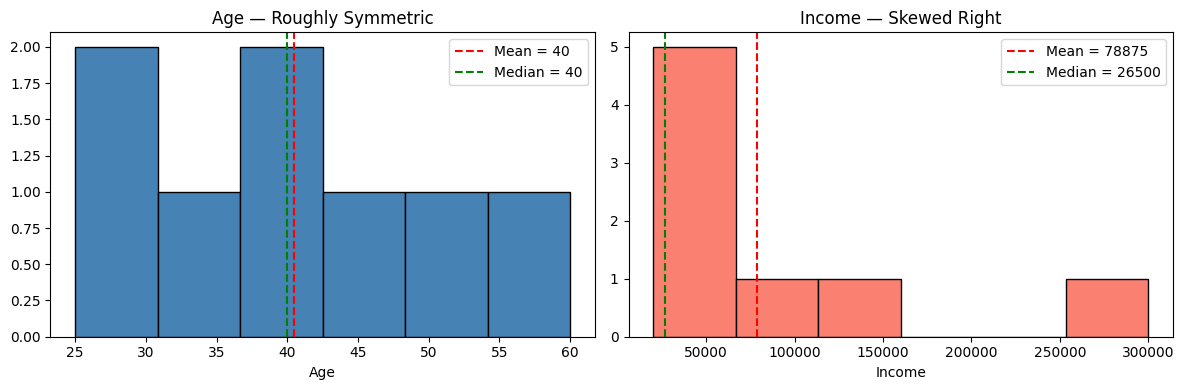

Notice how Income's mean (red) is pulled far to the right by a few big earners.
The median (green) is a better 'typical' value for skewed data.


In [4]:
# Problem 2: Income is "skewed" — most people earn modest amounts, a few earn a LOT
# Let's see this visually

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age — roughly balanced
axes[0].hist(df['Age'].dropna(), bins=6, color='steelblue', edgecolor='black')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean = {df['Age'].mean():.0f}")
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f"Median = {df['Age'].median():.0f}")
axes[0].set_title('Age — Roughly Symmetric')
axes[0].set_xlabel('Age')
axes[0].legend()

# Income — skewed right
axes[1].hist(df['Income'].dropna(), bins=6, color='salmon', edgecolor='black')
axes[1].axvline(df['Income'].mean(), color='red', linestyle='--', label=f"Mean = {df['Income'].mean():.0f}")
axes[1].axvline(df['Income'].median(), color='green', linestyle='--', label=f"Median = {df['Income'].median():.0f}")
axes[1].set_title('Income — Skewed Right')
axes[1].set_xlabel('Income')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Notice how Income's mean (red) is pulled far to the right by a few big earners.")
print("The median (green) is a better 'typical' value for skewed data.")

In [5]:
# Problem 3: Missing values (NaN) — we'll deal with these after fixing the easy problems
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nOut of {df.size} total cells, {df.isnull().sum().sum()} are missing.")

Missing values per column:
PatientID         0
Gender            0
Age               2
Income            2
BloodPressure     2
Cholesterol       3
Diagnosis         2
FollowUp_Score    3
dtype: int64

Out of 80 total cells, 14 are missing.


---

# 3. Fix the Easy Problems First

Let's fix what we can quickly — text inconsistencies — before tackling missing values.

## 3a. Fix Upper/Lower Case Issues

In [6]:
# .str.title() converts any text to "Title Case" → "Male", "Female", "Normal", "High"
df['Gender'] = df['Gender'].str.title()
df['BloodPressure'] = df['BloodPressure'].str.title()

print("Gender now:", df['Gender'].value_counts().to_dict())
print("BP now:    ", df['BloodPressure'].value_counts().to_dict())
print("\nClean! All consistent now.")

Gender now: {'Male': 5, 'Female': 5}
BP now:     {'Normal': 5, 'High': 3}

Clean! All consistent now.


Case issues and skewness are noted. Now let's focus on the **main challenge** — missing values.

---

# 4. Understanding Missing Values

## 4a. Where are the missing values?

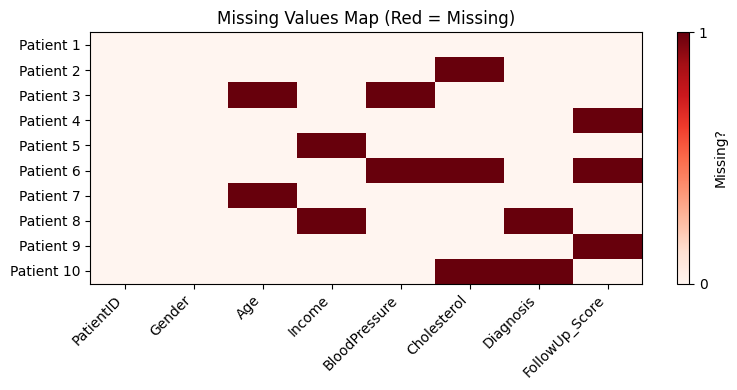

In [7]:
# Let's visualise exactly where the missing values are in the dataset
plt.figure(figsize=(8, 4))
plt.imshow(df.isnull(), cmap='Reds', aspect='auto')
plt.xticks(range(len(df.columns)), df.columns, rotation=45, ha='right')
plt.yticks(range(len(df)), [f"Patient {i}" for i in df['PatientID']])
plt.title('Missing Values Map (Red = Missing)')
plt.colorbar(label='Missing?', ticks=[0, 1])
plt.tight_layout()
plt.show()

## 4b. Why Are Values Missing?

Not all missing data is the same. **The reason a value is missing matters a lot.** There are three types:

---

**MCAR — Missing Completely At Random**
> The value is missing by **pure accident**. No pattern at all.
>
> *In our data:* `Age` is missing for patients 3 and 7 — the nurse simply forgot to write it down. It has nothing to do with their actual age or anything else.

**MAR — Missing At Random**  
> The value is missing because of **another column** in the data, but NOT because of the missing value itself.
>
> *In our data:* `Cholesterol` is missing because the doctor only ordered cholesterol tests for patients who had a diagnosis. The missingness is related to the `Diagnosis` column — not to the cholesterol level itself.

**MNAR — Missing Not At Random**
> The value is missing **because of what the value would have been**.
>
> *In our data:* `Income` is missing because high-income people tend to skip the income question. The very reason it's missing IS the income value itself.

## 4c. Summary of Missing Values

| Column | Missing? | Mechanism | Why? |
|--------|----------|-----------|------|
| `Age` | 2 missing | **MCAR** | Nurse forgot — pure accident, no pattern |
| `Income` | 2 missing | **MNAR** | High earners skip the question — missingness depends on the value itself |
| `BloodPressure` | 2 missing | **MCAR** | Random data entry errors |
| `Cholesterol` | 3 missing | **MAR** | Doctor ordered tests based on diagnosis — depends on another column |
| `Diagnosis` | 2 missing | **MCAR** | Paperwork lost — random accident |
| `FollowUp_Score` | 3 missing | **MAR** | Patients who were sicker or busier missed follow-ups — related to other variables |

Now let's learn different ways to handle these missing values.

---

# 5. Handling Missing Values

There are two main approaches:
- **Deletion methods** — remove the missing data
- **Imputation methods** — fill in the missing data with a reasonable estimate

We'll use a **fresh copy** of the data for every strategy so we can compare them fairly.



---

## 5A. Deletion Methods

These methods deal with missing data by **throwing away** the parts that are incomplete.



---

### Strategy 1: Complete Case Analysis (Listwise Deletion)

**The simplest approach:** just delete every row that has ANY missing value.

- **Good:** Very easy, no guessing needed
- **Bad:** We can lose a LOT of data. If a row has 7 good values and 1 missing, we throw away all 7!

In [8]:
df_complete = df.dropna()

print(f"Before: {len(df)} rows")
print(f"After:  {len(df_complete)} rows")
print(f"We lost {len(df) - len(df_complete)} rows — that's {(len(df) - len(df_complete))/len(df)*100:.0f}% of our data gone!\n")

df_complete

Before: 10 rows
After:  1 rows
We lost 9 rows — that's 90% of our data gone!



,PatientID,Gender,Age,Income,BloodPressure,Cholesterol,Diagnosis,FollowUp_Score
0,1,Male,25.0,20000.0,Normal,180.0,No,70.0


---

### Strategy 2: Available Case Analysis (Pairwise Deletion)

**A smarter version of deletion:** instead of deleting the whole row, only skip the specific missing cell when doing calculations. The rest of the row's data is still used.

For example, when calculating the average Age, we skip patients with missing Age but still use their Income, Cholesterol, etc. for other calculations.

In [9]:
# Available case: each column uses ALL its non-missing values
# Complete case: only uses rows where EVERYTHING is present

print("Available Case — uses all non-missing values per column:")
print(f"  Age mean:        {df['Age'].mean():.1f}  (using {df['Age'].count()} patients)")
print(f"  Income mean:     {df['Income'].mean():.0f}  (using {df['Income'].count()} patients)")
print(f"  Cholesterol mean:{df['Cholesterol'].mean():.1f}  (using {df['Cholesterol'].count()} patients)")

print(f"\nComplete Case — only uses the {len(df_complete)} rows with NO missing values:")
print(f"  Age mean:        {df_complete['Age'].mean():.1f}  (using {len(df_complete)} patients)")
print(f"  Income mean:     {df_complete['Income'].mean():.0f}  (using {len(df_complete)} patients)")
print(f"  Cholesterol mean:{df_complete['Cholesterol'].mean():.1f}  (using {len(df_complete)} patients)")

print("\n→ Available case uses MORE data for each calculation, so results are usually more reliable.")

Available Case — uses all non-missing values per column:
  Age mean:        40.5  (using 8 patients)
  Income mean:     78875  (using 8 patients)
  Cholesterol mean:207.9  (using 7 patients)

Complete Case — only uses the 1 rows with NO missing values:
  Age mean:        25.0  (using 1 patients)
  Income mean:     20000  (using 1 patients)
  Cholesterol mean:180.0  (using 1 patients)

→ Available case uses MORE data for each calculation, so results are usually more reliable.


---

## 5B. Imputation Methods

Instead of deleting missing data, these methods **fill in** the blanks with a reasonable estimate. This way we keep all our rows.



---

### Strategy 3: Mean / Median / Mode Imputation

The most common approach — fill missing values with a summary of the existing data:

- **Mean** (average) → for numbers that are evenly spread
- **Median** (middle value) → for numbers that are **skewed** (like Income — remember the histogram!)
- **Mode** (most frequent value) → for categories (like Gender, BloodPressure)

In [10]:
df_mmm = df.copy()

# Age is fairly even → use MEAN
df_mmm['Age'] = df_mmm['Age'].fillna(df_mmm['Age'].mean())
print(f"Age: filled with mean = {df['Age'].mean():.1f}")

# Income is skewed → use MEDIAN (mean would be too high — remember the histogram!)
df_mmm['Income'] = df_mmm['Income'].fillna(df_mmm['Income'].median())
print(f"Income: filled with median = {df['Income'].median():.0f}  (mean was {df['Income'].mean():.0f} — too high!)")

# BloodPressure is a category → use MODE (most common value)
df_mmm['BloodPressure'] = df_mmm['BloodPressure'].fillna(df_mmm['BloodPressure'].mode()[0])
print(f"BloodPressure: filled with mode = '{df['BloodPressure'].mode()[0]}'")

# Diagnosis is a category → use MODE
df_mmm['Diagnosis'] = df_mmm['Diagnosis'].fillna(df_mmm['Diagnosis'].mode()[0])
print(f"Diagnosis: filled with mode = '{df['Diagnosis'].mode()[0]}'")

# Cholesterol is fairly even → use MEAN
df_mmm['Cholesterol'] = df_mmm['Cholesterol'].fillna(df_mmm['Cholesterol'].mean())
print(f"Cholesterol: filled with mean = {df['Cholesterol'].mean():.1f}")

# FollowUp_Score is fairly even → use MEAN
df_mmm['FollowUp_Score'] = df_mmm['FollowUp_Score'].fillna(df_mmm['FollowUp_Score'].mean())
print(f"FollowUp_Score: filled with mean = {df['FollowUp_Score'].mean():.1f}")

print(f"\nMissing values remaining: {df_mmm.isnull().sum().sum()}")
df_mmm

Age: filled with mean = 40.5
Income: filled with median = 26500  (mean was 78875 — too high!)
BloodPressure: filled with mode = 'Normal'
Diagnosis: filled with mode = 'No'
Cholesterol: filled with mean = 207.9
FollowUp_Score: filled with mean = 71.6

Missing values remaining: 0


,PatientID,Gender,Age,Income,BloodPressure,Cholesterol,Diagnosis,FollowUp_Score
0,1,Male,25.0,20000.0,Normal,180.000000,No,70.000000
1,2,Female,34.0,22000.0,High,207.857143,No,65.000000
2,3,Female,40.5,95000.0,Normal,210.000000,Yes,80.000000
3,4,Male,45.0,25000.0,Normal,240.000000,Yes,71.571429
4,5,Male,29.0,26500.0,Normal,190.000000,No,72.000000
5,6,Female,51.0,120000.0,Normal,207.857143,Yes,71.571429
6,7,Male,40.5,21000.0,High,175.000000,No,68.000000
7,8,Female,38.0,26500.0,Normal,200.000000,No,75.000000
8,9,Male,60.0,300000.0,High,260.000000,Yes,71.571429
9,10,Female,42.0,28000.0,Normal,207.857143,No,71.000000


---

### Strategy 4: Regression Imputation

**Idea:** Instead of just using the average, use OTHER columns to **predict** the missing value.

It's like saying: *"Based on this patient's Age and Income, what would their Cholesterol likely be?"*

This is smarter because it considers the relationships between columns.

In [11]:
from sklearn.linear_model import LinearRegression

df_reg = df.copy()

# First, fill Age and Income (we need them as inputs for the prediction)
df_reg['Age'] = df_reg['Age'].fillna(df_reg['Age'].mean())
df_reg['Income'] = df_reg['Income'].fillna(df_reg['Income'].median())

# Step 1: Separate rows that HAVE Cholesterol from rows that DON'T
has_value = df_reg['Cholesterol'].notna()

train_X = df_reg.loc[has_value, ['Age', 'Income']]    # inputs
train_y = df_reg.loc[has_value, 'Cholesterol']         # what we're predicting
missing_X = df_reg.loc[~has_value, ['Age', 'Income']]  # rows we need to predict

# Step 2: Train a simple model
model = LinearRegression()
model.fit(train_X, train_y)

# Step 3: Predict the missing Cholesterol values
predicted = model.predict(missing_X)
df_reg.loc[~has_value, 'Cholesterol'] = predicted

# Show what happened
print("Predicted Cholesterol for patients with missing values:\n")
for idx, val in zip(missing_X.index, predicted):
    pid = df_reg.loc[idx, 'PatientID']
    age = df_reg.loc[idx, 'Age']
    inc = df_reg.loc[idx, 'Income']
    print(f"  Patient {pid:.0f} (Age={age:.0f}, Income={inc:.0f}) → Cholesterol = {val:.1f}")

Predicted Cholesterol for patients with missing values:

  Patient 2 (Age=34, Income=22000) → Cholesterol = 193.9
  Patient 6 (Age=51, Income=120000) → Cholesterol = 232.1
  Patient 10 (Age=42, Income=28000) → Cholesterol = 209.4


In [12]:
df_reg

,PatientID,Gender,Age,Income,BloodPressure,Cholesterol,Diagnosis,FollowUp_Score
0,1,Male,25.0,20000.0,Normal,180.000000,No,70.0
1,2,Female,34.0,22000.0,High,193.864439,No,65.0
2,3,Female,40.5,95000.0,NaN,210.000000,Yes,80.0
3,4,Male,45.0,25000.0,Normal,240.000000,Yes,NaN
4,5,Male,29.0,26500.0,Normal,190.000000,No,72.0
5,6,Female,51.0,120000.0,NaN,232.106061,Yes,NaN
6,7,Male,40.5,21000.0,High,175.000000,No,68.0
7,8,Female,38.0,26500.0,Normal,200.000000,NaN,75.0
8,9,Male,60.0,300000.0,High,260.000000,Yes,NaN
9,10,Female,42.0,28000.0,Normal,209.390217,NaN,71.0


---

### Strategy 5: Dummy Variable Imputation

**Idea:** Fill the missing value with something simple (like the mean), BUT also add a **new column** that marks "this value was missing."

Think of it like filling in a blank on a form and putting a sticky note that says *"I guessed this one."*

This way, any future analysis knows which values are real and which were filled in.

In [13]:
df_dummy = df.copy()

# Step 1: Create a "flag" column BEFORE we fill in the blanks (1 = was missing, 0 = was real)
df_dummy['Cholesterol_WasMissing'] = df_dummy['Cholesterol'].isnull().astype(int)
df_dummy['FollowUp_WasMissing'] = df_dummy['FollowUp_Score'].isnull().astype(int)

# Step 2: Now fill the missing values with the mean
df_dummy['Cholesterol'] = df_dummy['Cholesterol'].fillna(df_dummy['Cholesterol'].mean())
df_dummy['FollowUp_Score'] = df_dummy['FollowUp_Score'].fillna(df_dummy['FollowUp_Score'].mean())

# See the result — the flag tells us which values are real vs filled-in
df_dummy[['PatientID', 'Cholesterol', 'Cholesterol_WasMissing', 'FollowUp_Score', 'FollowUp_WasMissing']]

,PatientID,Cholesterol,Cholesterol_WasMissing,FollowUp_Score,FollowUp_WasMissing
0,1,180.000000,0,70.000000,0
1,2,207.857143,1,65.000000,0
2,3,210.000000,0,80.000000,0
3,4,240.000000,0,71.571429,1
4,5,190.000000,0,72.000000,0
5,6,207.857143,1,71.571429,1
6,7,175.000000,0,68.000000,0
7,8,200.000000,0,75.000000,0
8,9,260.000000,0,71.571429,1
9,10,207.857143,1,71.000000,0


---

### Strategy 6: Hot-Deck Imputation

**Idea:** Find the patient who is MOST SIMILAR to the one with the missing value, and **copy their value**.

For example, if Patient 4 is missing FollowUp_Score, we look for another patient with a similar Age and Income, and use their score.

The filled-in value is always a **real value** from the dataset — not an average or a prediction.

In [14]:
from sklearn.neighbors import NearestNeighbors

df_hd = df.copy()

# Fill Age & Income first (we use them to find "similar" patients)
df_hd['Age'] = df_hd['Age'].fillna(df_hd['Age'].mean())
df_hd['Income'] = df_hd['Income'].fillna(df_hd['Income'].median())

# Find nearest neighbour for patients missing FollowUp_Score
has_score = df_hd['FollowUp_Score'].notna()

donors = df_hd.loc[has_score]       # patients WITH the score (they "donate")
recipients = df_hd.loc[~has_score]  # patients WITHOUT the score (they "receive")

# Find the closest donor for each recipient based on Age and Income
nn = NearestNeighbors(n_neighbors=1)
nn.fit(donors[['Age', 'Income']])
_, indices = nn.kneighbors(recipients[['Age', 'Income']])

# Copy the donor's score to the recipient
donor_idx = donors.index[indices.flatten()]
df_hd.loc[~has_score, 'FollowUp_Score'] = donors.loc[donor_idx, 'FollowUp_Score'].values

print("Who donated to whom?\n")
for r, d in zip(recipients.index, donor_idx):
    print(f"  Patient {df_hd.loc[r,'PatientID']:.0f} (Age={df_hd.loc[r,'Age']:.0f}) "
          f"← got score from Patient {df_hd.loc[d,'PatientID']:.0f} "
          f"(Age={df_hd.loc[d,'Age']:.0f}, Score={df_hd.loc[r,'FollowUp_Score']:.0f})")

Who donated to whom?

  Patient 4 (Age=45) ← got score from Patient 8 (Age=38, Score=75)
  Patient 6 (Age=51) ← got score from Patient 3 (Age=40, Score=80)
  Patient 9 (Age=60) ← got score from Patient 3 (Age=40, Score=80)


---

### Strategy 7: Last Observation Carried Forward (LOCF)

**Idea:** If the data is in **order** (like dates or time), fill each missing value with the **last known value** from the row above.

Think of a thermometer that stops working — you'd assume the temperature is roughly the same as the last reading until you get a new one.

In [15]:
df_locf = df.copy()

# Show before and after side by side
print("FollowUp_Score — Before vs After LOCF:\n")
print(f"{'Patient':<10} {'Before':<10} {'After LOCF':<10}")
print("-" * 35)

filled = df_locf['FollowUp_Score'].ffill()  # forward fill

for i, row in df_locf.iterrows():
    before = "NaN" if pd.isna(row['FollowUp_Score']) else f"{row['FollowUp_Score']:.0f}"
    after = f"{filled[i]:.0f}"
    marker = " ← filled!" if pd.isna(row['FollowUp_Score']) else ""
    print(f"{row['PatientID']:<10} {before:<10} {after:<10}{marker}")

FollowUp_Score — Before vs After LOCF:

Patient    Before     After LOCF
-----------------------------------
1          70         70        
2          65         65        
3          80         80        
4          NaN        80         ← filled!
5          72         72        
6          NaN        72         ← filled!
7          68         68        
8          75         75        
9          NaN        75         ← filled!
10         71         71        


---

# 6. Quick Reference — Which Method to Use?

| Method | When to Use | Downside |
|--------|------------|----------|
| **Complete Case** | Few missing values, missing by pure chance (MCAR) | Loses lots of data |
| **Available Case** | You want to keep as much data as possible per calculation | Different calculations use different amounts of data |
| **Mean/Median/Mode** | Quick and simple; use median for skewed data, mode for categories | Every missing value gets the same fill — ignores patterns |
| **Regression** | Columns are related to each other (MAR) | Needs enough data to build a good model |
| **Dummy Variable** | You want to remember which values were filled in | Adds extra columns |
| **Hot-Deck** | You want filled values to be realistic (actual observed values) | Needs a good way to measure "similarity" |
| **LOCF** | Data is ordered by time | Assumes things don't change much over time |

**There is no single best method.** The right choice depends on your data and *why* the values are missing (MCAR, MAR, or MNAR).